In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

here = Path.cwd().resolve()
ROOT = next((p for p in [here, *here.parents]
             if (p / 'README.md').exists() and (p / 'notebooks').exists()), None)
if ROOT is None:
    raise FileNotFoundError('未找到项目根目录，请从仓库内运行 Notebook。')
env_file = ROOT / '.env'
if not env_file.exists():
    raise FileNotFoundError('缺少 .env：请复制 .env.example 并填写本机数据库信息。')
load_dotenv(env_file)
required = ['MYSQL_USER', 'MYSQL_PWD', 'MYSQL_HOST', 'MYSQL_DB']
missing = [key for key in required if not os.getenv(key)]
if missing:
    raise RuntimeError(f'.env 缺少配置项：{missing}')
DASHBOARD_DIR = ROOT / 'dashboard' / '03'
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
engine = create_engine(URL.create("mysql+pymysql",
    username=os.getenv("MYSQL_USER"), password=os.getenv("MYSQL_PWD"),
    host=os.getenv("MYSQL_HOST"), port=int(os.getenv("MYSQL_PORT", 3306)),
    database=os.getenv("MYSQL_DB"), query={"charset": "utf8mb4"}))
print('本地配置已加载，数据库连接已创建。')

本地配置已加载，数据库连接已创建。


     SKU数           销售额  销售额占比
ABC                           
A       7  2.707084e+07   76.9
B      16  6.364240e+06   18.1
C      95  1.779346e+06    5.1


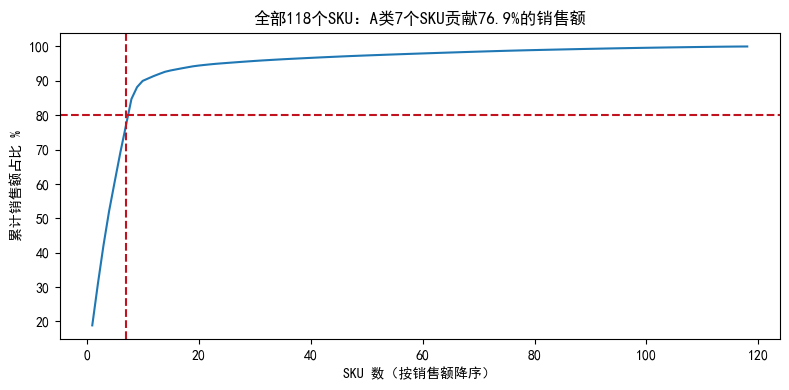

In [2]:
sku = pd.read_sql("""
    SELECT f.product_card_id, p.product_name, p.product_price,
           SUM(f.sales) AS sku_sales,
           SUM(f.order_item_quantity) AS total_qty
    FROM fact_order_item f
    JOIN dim_product p ON f.product_card_id = p.product_card_id
    WHERE f.order_status NOT IN ('CANCELED','SUSPECTED_FRAUD')
    GROUP BY f.product_card_id, p.product_name, p.product_price
""", engine)

# 按销售额降序 → 算累计占比 → 切 ABC
sku = sku.sort_values('sku_sales', ascending=False).reset_index(drop=True)
sku['cum_pct'] = sku['sku_sales'].cumsum() / sku['sku_sales'].sum()
sku['ABC'] = np.where(sku['cum_pct'] <= 0.80, 'A',
              np.where(sku['cum_pct'] <= 0.95, 'B', 'C'))

print(sku.groupby('ABC').agg(SKU数=('product_card_id','size'),
                             销售额=('sku_sales','sum')).assign(
      销售额占比=lambda d: (d['销售额']/d['销售额'].sum()*100).round(1)))

# 帕累托曲线
plt.figure(figsize=(8,4))
plt.plot(range(1, len(sku)+1), sku['cum_pct']*100)
plt.axhline(80, color='#c1121f', ls='--'); plt.axvline(7, color='#c1121f', ls='--')
plt.title('全部118个SKU：A类7个SKU贡献76.9%的销售额')
plt.xlabel('SKU 数（按销售额降序）'); plt.ylabel('累计销售额占比 %')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / 'SKU帕累托图.png', dpi=200, bbox_inches='tight')
plt.show()

In [3]:
# 读周需求（此时只有"有销量的周"）
wk = pd.read_sql("""
    SELECT product_card_id, YEARWEEK(order_date_key,3) AS yw,
           SUM(order_item_quantity) AS qty
    FROM fact_order_item
    WHERE order_status NOT IN ('CANCELED','SUSPECTED_FRAUD')
    GROUP BY product_card_id, YEARWEEK(order_date_key,3)
""", engine)

# ⭐补零范围 = 每个 SKU 自己的"在售窗口"（首销周→末销周），不是全期 162 周
# 依据：数据无下架字段，但活跃 SKU 数连续 27 个月恒定 54 个，2017-04 / 2017-09 两次整批换血
#（45 / 40 个 SKU 同月末销，33 / 13 个新 SKU 同月首销）→ 商品目录整批切换，不是需求波动。
# 停售后的零不是"零需求"而是"商品不存在"（结构性零），不进波动样本；
# 在售窗口内没卖出的周是真实零需求（抽样零），照补。
all_weeks = np.sort(wk['yw'].unique())
wk['wi'] = wk['yw'].map({w: i for i, w in enumerate(all_weeks)})    # 周序号（跨年连续）

span = wk.groupby('product_card_id')['wi'].agg(first='min', last='max')
span['win'] = span['last'] - span['first'] + 1                       # 在售窗口长度（周）

# 全期网格 → 只保留各 SKU 自己窗口内的周 → 窗口内补零
grid = pd.MultiIndex.from_product(
    [sku['product_card_id'].unique(), range(len(all_weeks))],
    names=['product_card_id', 'wi']).to_frame(index=False)
grid = grid.join(span[['first', 'last']], on='product_card_id')
grid = grid[(grid['wi'] >= grid['first']) & (grid['wi'] <= grid['last'])]
wk_win = grid.merge(wk[['product_card_id', 'wi', 'qty']],
                    on=['product_card_id', 'wi'], how='left').fillna({'qty': 0})
print(f"窗口内网格 {len(wk_win)} 行（=各 SKU 窗口长度之和）| 有销量 {len(wk)} 行"
      f" → 窗口内填充率 {len(wk)/len(wk_win)*100:.0f}%（在售期销售高度连续，波动其实不大）")

# CV = 标准差 ÷ 平均值（窗口内）
cv = wk_win.groupby('product_card_id')['qty'].agg(mu='mean', sigma='std').reset_index()
cv = cv.join(span['win'], on='product_card_id')
cv['CV'] = cv['sigma'] / cv['mu']

MIN_WIN = 8   # 窗口<8周的新品历史太短，σ/CV 估不准——新品按上市计划管理，不进统计分级
cv['XYZ'] = np.where(cv['win'] < MIN_WIN, '历史不足',
             np.where(cv['CV'] < 0.5, 'X',
              np.where(cv['CV'] < 1.0, 'Y', 'Z')))
print(cv['XYZ'].value_counts().reindex(['X', 'Y', 'Z', '历史不足']).to_string())

窗口内网格 7607 行（=各 SKU 窗口长度之和）| 有销量 6972 行 → 窗口内填充率 92%（在售期销售高度连续，波动其实不大）
XYZ
X       17
Y       70
Z       15
历史不足    16


In [4]:
# ── 口径敏感性存档：同一份数据，三种补零范围，三个不同的 XYZ 世界 ──
# ① 不补零（只用有销量的周）  ：漏掉在售期内真实的零需求周 → 波动被低估，人人都"稳定"
# ② 全期 162 周补零（第一版口径）：把停售期当零需求 → CV 被高估，96/118 被误判成 Z；
#    同时大量零点把 σ 拉平 → 三策略总资金被低估一半多（51 万 vs 115 万）——一个错口径两头错
# ③ 在售窗口内补零（本口径）  ：窗口内的零是真零照补，停售期不进样本
cv_nz = wk.groupby('product_card_id')['qty'].agg(mu='mean', sigma='std')           # ① 不补零
full_grid = pd.MultiIndex.from_product(
    [sku['product_card_id'].unique(), all_weeks],
    names=['product_card_id', 'yw']).to_frame(index=False)
cv_fz = (full_grid.merge(wk[['product_card_id', 'yw', 'qty']],
                         on=['product_card_id', 'yw'], how='left')
                  .fillna({'qty': 0})
                  .groupby('product_card_id')['qty'].agg(mu='mean', sigma='std'))  # ② 全期补零

def xyz_dist(c):
    lab = np.where(c['sigma'] / c['mu'] < 0.5, 'X',
           np.where(c['sigma'] / c['mu'] < 1.0, 'Y', 'Z'))
    return pd.Series(lab).value_counts().reindex(['X', 'Y', 'Z']).fillna(0).astype(int).to_dict()

print("① 不补零       :", xyz_dist(cv_nz))
print("② 全期补零(旧) :", xyz_dist(cv_fz))
print("③ 在售窗口(本) :", cv.loc[cv['XYZ'] != '历史不足', 'XYZ'].value_counts().reindex(['X','Y','Z']).to_dict(),
      "＋ 历史不足", int((cv['XYZ'] == '历史不足').sum()), "个")

① 不补零       : {'X': 42, 'Y': 73, 'Z': 3}
② 全期补零(旧) : {'X': 9, 'Y': 13, 'Z': 96}
③ 在售窗口(本) : {'X': 17, 'Y': 70, 'Z': 15} ＋ 历史不足 16 个


In [5]:
# ABC（钱的维度）× XYZ（波动维度）合体 → 九宫格底表 mix，后续安全库存测算都基于它
mix_all = sku.merge(cv, on='product_card_id')
new_sku = mix_all[mix_all['XYZ'] == '历史不足']
mix = mix_all[mix_all['XYZ'] != '历史不足'].copy()
print(f"参与测算 {len(mix)} 个 SKU；'历史不足'新品 {len(new_sku)} 个不进统计分级"
      f"（仅占销售额 {new_sku['sku_sales'].sum()/mix_all['sku_sales'].sum()*100:.2f}%，按上市计划另管）")

# 九宫格两张底表：SKU 数量（管理精力在哪） & 销售额（钱在哪）
grid_cnt = (mix.pivot_table(index='ABC', columns='XYZ',
                            values='product_card_id', aggfunc='size', fill_value=0)
            .reindex(index=list('ABC'), columns=list('XYZ'), fill_value=0))
grid_sales = (mix.pivot_table(index='ABC', columns='XYZ',
                              values='sku_sales', aggfunc='sum', fill_value=0)
              .reindex(index=list('ABC'), columns=list('XYZ'), fill_value=0))
print("\n九宫格 SKU 数：\n", grid_cnt)
print("\n九宫格销售额(万)：\n", (grid_sales / 1e4).round(0))

参与测算 102 个 SKU；'历史不足'新品 16 个不进统计分级（仅占销售额 0.95%，按上市计划另管）

九宫格 SKU 数：
 XYZ  X   Y   Z
ABC           
A    7   0   0
B    2   3  10
C    8  67   5

九宫格销售额(万)：
 XYZ       X      Y      Z
ABC                      
A    2707.0    0.0    0.0
B     398.0   18.0  210.0
C      11.0  137.0    6.0


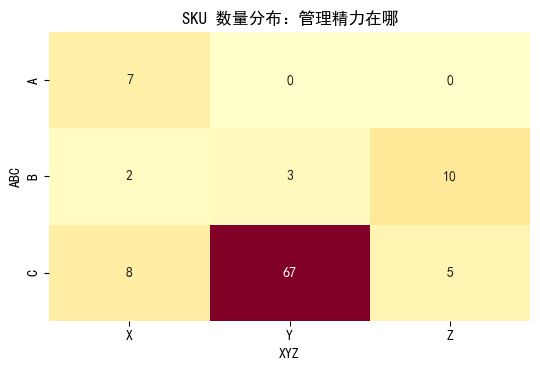

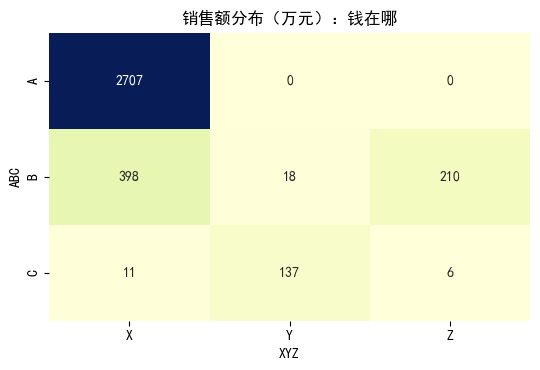

In [6]:
import seaborn as sns
heatmaps = [
    (grid_cnt, 'd', 'YlOrRd', 'SKU 数量分布：管理精力在哪', 'ABC-XYZ九宫格-SKU数量.png'),
    (grid_sales/1e4, '.0f', 'YlGnBu', '销售额分布（万元）：钱在哪', 'ABC-XYZ九宫格-销售额.png'),
]
for data, fmt, cmap, title, filename in heatmaps:
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, cbar=False, ax=ax)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(DASHBOARD_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()

In [7]:
from scipy.stats import norm

# ⭐ 假设（必须显式写出，数据里没有）
LEAD_TIME_WEEKS = 2       # 补货提前期假设 2 周
# 用商品单价近似库存成本（实际应用采购成本，数据未提供）

sl_matrix = {('A','X'):0.97, ('A','Y'):0.98, ('A','Z'):0.99,
             ('B','X'):0.94, ('B','Y'):0.95, ('B','Z'):0.96,
             ('C','X'):0.88, ('C','Y'):0.86, ('C','Z'):0.85}

mix['SL_差异化'] = mix.apply(lambda r: sl_matrix[(r['ABC'], r['XYZ'])], axis=1)
mix['SL_一刀切'] = 0.95

for tag in ['一刀切', '差异化']:
    z = norm.ppf(mix[f'SL_{tag}'])                                  # 服务水平 → z 值
    mix[f'安全库存_{tag}'] = z * mix['sigma'] * np.sqrt(LEAD_TIME_WEEKS)  # ⭐ z × σ × √L
    mix[f'资金_{tag}'] = mix[f'安全库存_{tag}'] * mix['product_price']

cut  = mix['资金_一刀切'].sum()
diff = mix['资金_差异化'].sum()
print(f"策略一 一刀切(95%)  安全库存资金: {cut/1e4:8.0f} 万")
print(f"策略二 差异化        安全库存资金: {diff/1e4:8.0f} 万")
print(f"差额(可释放资金):                {(cut-diff)/1e4:8.0f} 万  ({(cut-diff)/cut*100:.1f}%)")

策略一 一刀切(95%)  安全库存资金:      115 万
策略二 差异化        安全库存资金:      120 万
差额(可释放资金):                      -5 万  (-4.2%)


     SKU数  一刀切资金  差异化资金   节省
ABC                         
A       7    6.0    7.0 -1.0
B      15  103.0  109.0 -6.0
C      80    7.0    5.0  2.0


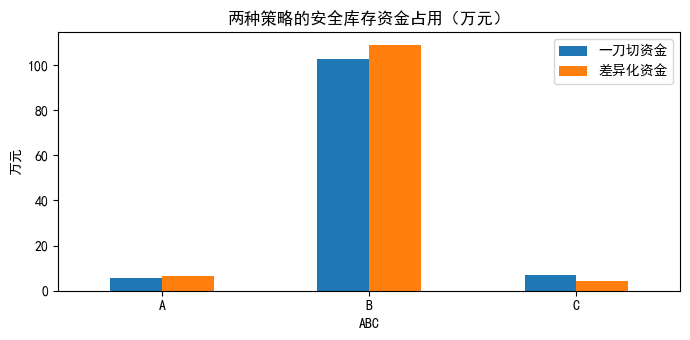

In [8]:
by_abc = mix.groupby('ABC').agg(
    SKU数=('product_card_id','size'),
    一刀切资金=('资金_一刀切','sum'),
    差异化资金=('资金_差异化','sum')).assign(
    节省=lambda d: d['一刀切资金']-d['差异化资金'])
print((by_abc[['SKU数']].join((by_abc[['一刀切资金','差异化资金','节省']]/1e4).round(0))))

(by_abc[['一刀切资金','差异化资金']]/1e4).plot(kind='bar', figsize=(7,3.5))
plt.title('两种策略的安全库存资金占用（万元）'); plt.ylabel('万元'); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '一刀切和差异化安全库存对比.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# 策略三：只降C类，A/B维持95%
mix['SL_只降C'] = np.where(mix['ABC']=='C', 0.85, 0.95)
z3 = norm.ppf(mix['SL_只降C'])
mix['资金_只降C'] = z3 * mix['sigma'] * np.sqrt(LEAD_TIME_WEEKS) * mix['product_price']

for t in ['一刀切','差异化','只降C']:
    print(f"策略 {t:6s}: {mix[f'资金_{t}'].sum()/1e4:6.1f} 万")
print(f"\n只降C 相对一刀切节省: {(mix['资金_一刀切'].sum()-mix['资金_只降C'].sum())/1e4:.1f} 万")

策略 一刀切   :  115.2 万
策略 差异化   :  120.1 万
策略 只降C   :  112.6 万

只降C 相对一刀切节省: 2.6 万


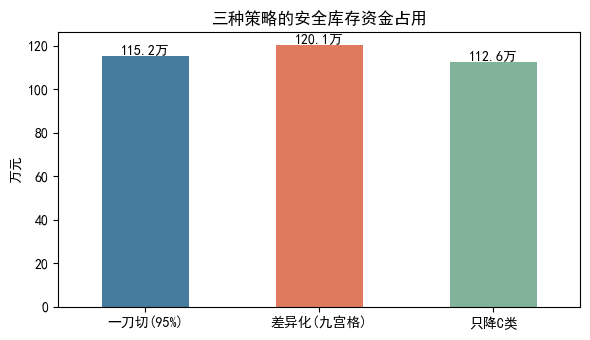

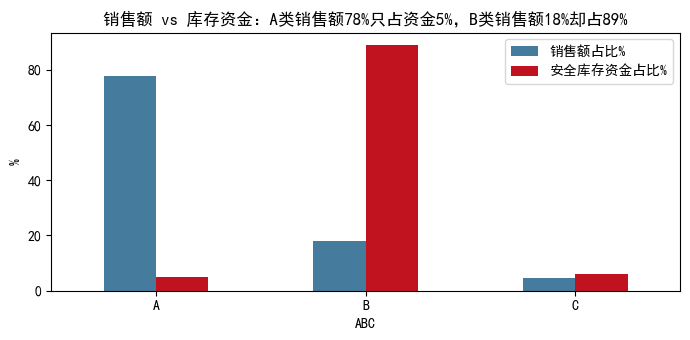

In [10]:
# 图1：三策略资金对比
res = pd.Series({
    '一刀切(95%)': mix['资金_一刀切'].sum()/1e4,
    '差异化(九宫格)': mix['资金_差异化'].sum()/1e4,
    '只降C类': mix['资金_只降C'].sum()/1e4})
ax = res.plot(kind='bar', figsize=(6,3.5), color=['#457b9d','#e07a5f','#81b29a'], rot=0)
for i,v in enumerate(res): ax.text(i, v+0.5, f'{v:.1f}万', ha='center')
plt.title('三种策略的安全库存资金占用'); plt.ylabel('万元')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '三种策略安全库存对比.png', dpi=200, bbox_inches='tight')
plt.show()

# 图2（更重要）：资金驱动因素 —— 销售额占比 vs 安全库存资金占比
cmp = pd.DataFrame({
    '销售额占比%': mix.groupby('ABC')['sku_sales'].sum()/mix['sku_sales'].sum()*100,
    '安全库存资金占比%': mix.groupby('ABC')['资金_一刀切'].sum()/mix['资金_一刀切'].sum()*100})
cmp.plot(kind='bar', figsize=(7,3.5), rot=0, color=['#457b9d','#c1121f'])
plt.title('销售额 vs 库存资金：A类销售额78%只占资金5%，B类销售额18%却占89%')
plt.ylabel('%'); plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '销售额vs库存资金.png', dpi=200, bbox_inches='tight')
plt.show()

## 判断③结论与假设

**结论**：对 102 个具有足够销售历史的可测算 SKU，一刀切 95% 服务水平的安全库存资金 **115.2 万**；教科书式九宫格差异化 **120.1 万（反贵 4.2%）**——因为它给 A/B 类抬了服务水平；只降 C 类 **112.6 万（省 2.2%）**。**资金真正的集中点与销售额无关**：A 类 7 个 SKU 贡献 77.6% 的销售额，却只占资金 5%，且全部属于 X（高销量+低波动，卖得最多的反而最好预测）；B 类（销售额 17.9%）吃掉 **89%** 资金，三因子叠加——2017 新目录上架（窗口约 50 周）× 单价最高（均 328）× 周 σ 最大（约 70）。**建议**：与其调服务水平（z 杠杆弱），不如压缩 B 类补货提前期——L 减半资金降 29%（约 30 万），或对 BZ 格改按单采购。

**假设与局限（显式声明）**：
1. 补货提前期 2 周、全 SKU 相同（数据无供应商/提前期字段）
2. 库存成本用商品单价近似（应为采购成本，数据未提供）
3. σ 用"在售窗口内补零"的周需求波动估计；窗口 <8 周的 16 个新品（销售额 0.95%）历史不足不参与，应按上市计划管理
4. 数据无库存快照——这是两种备货**策略的对比测算**，不是对现有库存的审计
5. 历史波动代表未来（平稳假设）；目录在数据期内已切换两次，实际应用需滚动重估